# 08 — Less-Laundered Charge Curve

nb07 winner: E2 RF MAE 0.0534 / R² 0.647; E2 LSTM global+stress 0.0585 / R² 0.607.
Two problems remain:
1. **LSTM can't beat RF** — the decisive signal is in scalars both models share; the CV-only
   pipeline strips the shape signal (duration, magnitude, CC ramp) that LSTM could use.
2. **RW9 still unrescued** (R² ≈ −0.21) — discriminative signal at high SOH lives in the
   CC ramp duration and absolute amplitude, both currently discarded.

**Hypothesis:** restoring a fixed-voltage-anchored CC ramp + explicit duration channel gives LSTM
shape signal RF can't summarise from reasonable scalars, rescuing RW9 without regressing RW1.

| Phase | Content |
|-------|---------|
| 0 | Diagnostic: choose V_ANCHOR empirically |
| 1 | Build `charge_curves_cc.npz` (headline D2) |
| 2 | Train D0/D1/D2 (RF + LSTM each) |
| 3 | Summary table + RW1/RW9 callouts |

## Phase 0 — Diagnostic: choose V_ANCHOR

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

ROOT      = Path("..") if Path("../src").exists() else Path(".")
PROCESSED = ROOT / "data" / "processed"
RESULTS   = ROOT / "results"
sys.path.insert(0, str(ROOT / "src"))

from battery       import load_controlled, load_randomized
from charge_curves import (
    CONTROLLED_MATS, RANDOMIZED_MATS,
    build_dataset_cc,
)
from curve_models  import LSTMRegPooled, per_sample_scale, jitter
from sequence      import train_model, predict_model

device = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else "cpu"
)
torch.manual_seed(42)
np.random.seed(42)
print(f"device: {device}")

device: mps


In [2]:
# ── Inline raw extraction for Phase 0 diagnostic ─────────────────────────────
# Mirrors pairing logic from charge_curves.py but returns raw arrays (not resampled)
# so we can inspect the full CC ramp shape.

ctrl_df  = pd.read_csv(PROCESSED / "controlled.csv")
rw_df    = pd.read_csv(PROCESSED / "randomized.csv")
labels   = pd.concat([ctrl_df, rw_df], ignore_index=True)

diag_records = []   # {battery_id, cycle_index, V_raw, I_raw, Time_raw, soh}

# Controlled
for bid, rel_path in CONTROLLED_MATS.items():
    cycles = load_controlled(ROOT / rel_path)
    pairs = []
    last_chg = None
    for cyc in cycles:
        ct = str(cyc.get("type", ""))
        if ct == "charge":   last_chg = cyc
        elif ct == "discharge": pairs.append((cyc, last_chg))

    cap_vals = []
    for dis, _ in pairs:
        d = dis["data"]
        t = np.asarray(d["Time"], float)
        I = np.asarray(d["Current_measured"], float)
        cap_vals.append(float(np.trapezoid(np.abs(I), t) / 3600))
    n_wu = max(5, int(0.10 * len(pairs)))
    base = max(cap_vals[:n_wu])
    kept = [(dis, chg) for (dis, chg), cap in zip(pairs, cap_vals) if cap > 0.5 * base]

    for new_idx, (dis, chg) in enumerate(kept):
        if chg is None: continue
        d = chg["data"]
        diag_records.append({
            "battery_id":  bid,
            "cycle_index": new_idx,
            "cohort":      "controlled",
            "V":    np.asarray(d["Voltage_measured"], float),
            "I":    np.asarray(d["Current_measured"], float),
            "Time": np.asarray(d["Time"], float),
        })

# Randomized
for bid, rel_path in RANDOMIZED_MATS.items():
    steps = load_randomized(ROOT / rel_path)
    raw_pairs, last_ref_chg = [], None
    for step in steps:
        stype   = str(step.get("type", "")).upper()
        comment = str(step.get("comment", "")).lower()
        is_ref  = "reference" in comment
        if stype == "C" and is_ref: last_ref_chg = step
        elif stype == "D" and is_ref:
            t = np.asarray(step["relativeTime"], float)
            I = np.asarray(step["current"], float)
            if len(t) < 2 or np.abs(I).mean() < 0.5: continue
            if float(t[-1] - t[0]) < 1200: continue
            raw_pairs.append((step, last_ref_chg))
    for new_idx, (dis, chg) in enumerate(raw_pairs[::2]):
        if chg is None: continue
        diag_records.append({
            "battery_id":  bid,
            "cycle_index": new_idx,
            "cohort":      "rw",
            "V":    np.asarray(chg["voltage"], float),
            "I":    np.asarray(chg["current"], float),
            "Time": np.asarray(chg["relativeTime"], float),
        })

# Merge SOH labels
lbl_map = labels.set_index(["battery_id","cycle_index"])["capacity_retention"].to_dict()
for r in diag_records:
    r["soh"] = lbl_map.get((r["battery_id"], r["cycle_index"]), float("nan"))
diag_records = [r for r in diag_records if not np.isnan(r["soh"])]
print(f"Diagnostic records: {len(diag_records)} across "
      f"{len({r['battery_id'] for r in diag_records})} batteries")

Diagnostic records: 794 across 13 batteries


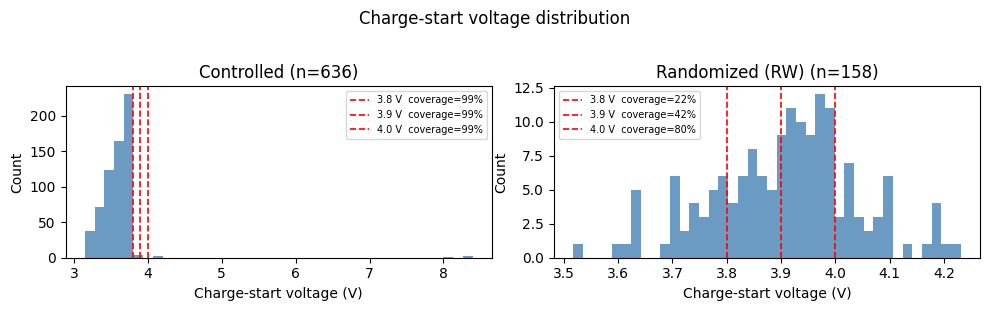


Coverage (fraction of cycles starting BELOW anchor):
  3.8 V  controlled=99%  rw=22%
  3.9 V  controlled=99%  rw=42%
  4.0 V  controlled=99%  rw=80%


In [3]:
# ── Plot 1: histogram of charge-start voltage, per cohort ────────────────────
ANCHORS = [3.8, 3.9, 4.0]

ctrl_v0 = [r["V"][0] for r in diag_records if r["cohort"] == "controlled"]
rw_v0   = [r["V"][0] for r in diag_records if r["cohort"] == "rw"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=False)
for ax, vals, title in zip(axes, [ctrl_v0, rw_v0], ["Controlled", "Randomized (RW)"]):
    ax.hist(vals, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
    for va in ANCHORS:
        frac = np.mean(np.array(vals) < va)
        ax.axvline(va, color="red", lw=1.2, ls="--",
                   label=f"{va} V  coverage={frac:.0%}")
    ax.set_xlabel("Charge-start voltage (V)")
    ax.set_ylabel("Count")
    ax.set_title(f"{title} (n={len(vals)})")
    ax.legend(fontsize=7)
fig.suptitle("Charge-start voltage distribution", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / "08_p0_start_voltage_hist.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nCoverage (fraction of cycles starting BELOW anchor):")
for va in ANCHORS:
    cc = np.mean(np.array(ctrl_v0) < va)
    rc = np.mean(np.array(rw_v0) < va)
    print(f"  {va} V  controlled={cc:.0%}  rw={rc:.0%}")

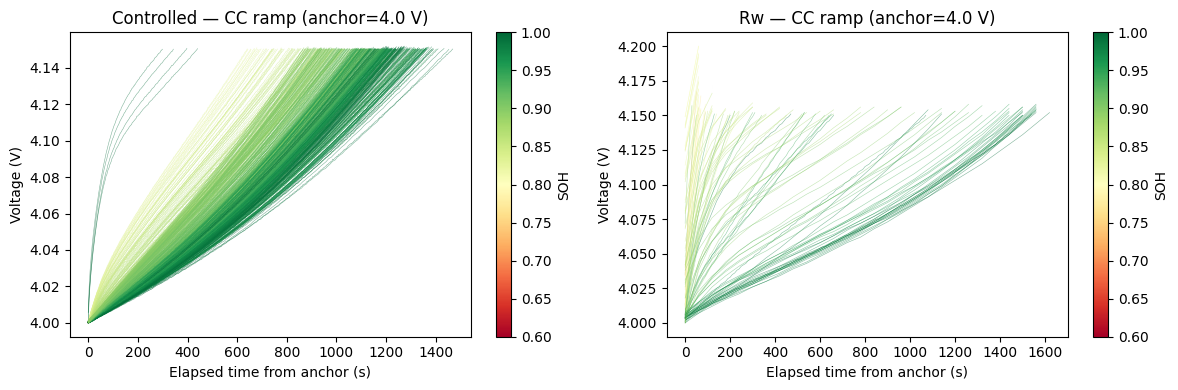

In [4]:
# ── Plot 2: anchored CC ramps overlaid, colored by SOH ───────────────────────
# Choose the anchor that has the best coverage per the histogram above.
V_ANCHOR = 4.0   # ← update after inspecting the histogram
V_CV     = 4.15  # existing CV onset

def extract_cc_ramp(V, Time, v_start, v_cv):
    """Return (Time_ramp - Time_anchor, V_ramp) or (None, None)."""
    if V[0] >= v_start:
        return None, None
    # First two-consecutive crossing of v_start
    above = np.where(V >= v_start)[0]
    i_anc = None
    for k in above:
        if k + 1 < len(V) and V[k + 1] >= v_start:
            i_anc = k; break
    if i_anc is None: return None, None
    # First two-consecutive crossing of v_cv
    above_cv = np.where(V[i_anc:] >= v_cv)[0]
    i_cv_rel = None
    for k in above_cv:
        if k + 1 < len(V[i_anc:]) and V[i_anc + k + 1] >= v_cv:
            i_cv_rel = k; break
    if i_cv_rel is None: return None, None
    i_cv = i_anc + i_cv_rel
    t_ramp = Time[i_anc: i_cv + 1] - Time[i_anc]
    v_ramp = V[i_anc: i_cv + 1]
    return t_ramp, v_ramp

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cohort in zip(axes, ["controlled", "rw"]):
    recs = [r for r in diag_records if r["cohort"] == cohort]
    cmap = plt.cm.RdYlGn
    for r in recs:
        t_r, v_r = extract_cc_ramp(r["V"], r["Time"], V_ANCHOR, V_CV)
        if t_r is None: continue
        ax.plot(t_r, v_r, color=cmap(r["soh"]), lw=0.4, alpha=0.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0.6, 1.0))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="SOH")
    ax.set_xlabel("Elapsed time from anchor (s)")
    ax.set_ylabel("Voltage (V)")
    ax.set_title(f"{cohort.capitalize()} — CC ramp (anchor={V_ANCHOR} V)")
plt.tight_layout()
plt.savefig(RESULTS / "08_p0_cc_ramp_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

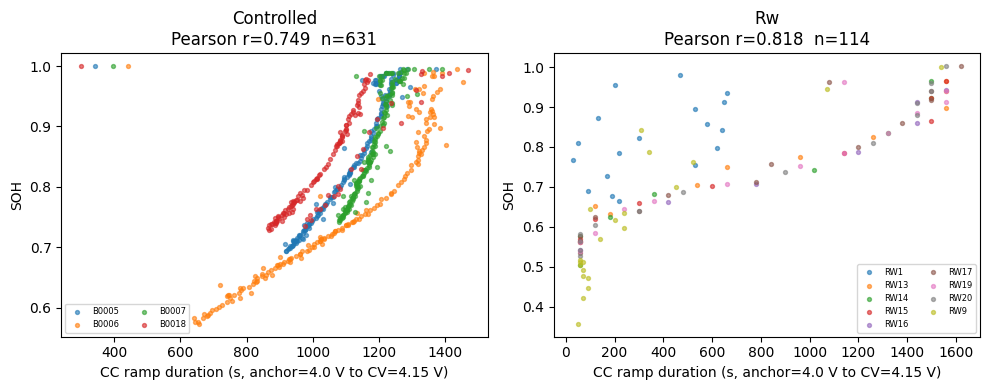


→ Inspect the scatter above.
  If Pearson |r| > 0.3 and RW coverage is adequate, keep V_ANCHOR.
  Otherwise try V_ANCHOR=3.9 V and re-run cells 3-4.


In [5]:
# ── Plot 3: scatter — time-from-anchor-to-CV vs SOH, per cohort ──────────────
results_diag = {"controlled": {"dt": [], "soh": [], "bid": []},
                "rw":         {"dt": [], "soh": [], "bid": []}}

for r in diag_records:
    V_, Ti_, soh_, coh_, bid_ = r["V"], r["Time"], r["soh"], r["cohort"], r["battery_id"]
    if V_[0] >= V_ANCHOR: continue
    above = np.where(V_ >= V_ANCHOR)[0]
    i_anc = None
    for k in above:
        if k + 1 < len(V_) and V_[k + 1] >= V_ANCHOR:
            i_anc = k; break
    above_cv = np.where(V_ >= V_CV)[0]
    i_cv = None
    for k in above_cv:
        if k + 1 < len(V_) and V_[k + 1] >= V_CV:
            i_cv = k; break
    if i_anc is None or i_cv is None or i_anc >= i_cv: continue
    dt = float(Ti_[i_cv] - Ti_[i_anc])
    results_diag[coh_]["dt"].append(dt)
    results_diag[coh_]["soh"].append(soh_)
    results_diag[coh_]["bid"].append(bid_)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cohort, d) in zip(axes, results_diag.items()):
    dt_arr  = np.array(d["dt"])
    soh_arr = np.array(d["soh"])
    bids    = np.array(d["bid"])
    for bid in np.unique(bids):
        m = bids == bid
        ax.scatter(dt_arr[m], soh_arr[m], s=8, alpha=0.6, label=bid)
    if len(dt_arr) > 1:
        from scipy.stats import pearsonr
        r_val, _ = pearsonr(dt_arr, soh_arr)
        ax.set_title(f"{cohort.capitalize()}\nPearson r={r_val:.3f}  n={len(dt_arr)}")
    ax.set_xlabel(f"CC ramp duration (s, anchor={V_ANCHOR} V to CV={V_CV} V)")
    ax.set_ylabel("SOH")
    ax.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS / "08_p0_cc_dt_vs_soh.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n→ Inspect the scatter above.")
print("  If Pearson |r| > 0.3 and RW coverage is adequate, keep V_ANCHOR.")
print("  Otherwise try V_ANCHOR=3.9 V and re-run cells 3-4.")

### Decision gate

After inspecting the plots above, update `V_ANCHOR` in the cell below and continue to Phase 1.

**Fallback:** if RW coverage < 30% (most charges start above the anchor), set `V_ANCHOR = None`
and D2 degrades gracefully to CV-only + time (same as D1). Document in the summary.

In [6]:
# ← Set based on Phase 0 findings
V_ANCHOR = 4.0
V_CV     = 4.15
I_CUT    = 0.04
N_PTS    = 128
print(f"V_ANCHOR={V_ANCHOR}  V_CV={V_CV}  I_CUT={I_CUT}  N_PTS={N_PTS}")

V_ANCHOR=4.0  V_CV=4.15  I_CUT=0.04  N_PTS=128


## Phase 1 — Build headline dataset (D2)

In [7]:
print("Extracting D2 (anchored CC+CV + time) dataset…")
df_cc = build_dataset_cc(
    ROOT, v_cv=V_CV, i_cut=I_CUT, n_points=N_PTS,
    v_start=V_ANCHOR,   # None → D1 (fallback) if anchor not viable
)

# Merge SOH labels from processed CSVs
ctrl_df = pd.read_csv(PROCESSED / "controlled.csv")
rw_df   = pd.read_csv(PROCESSED / "randomized.csv")
labels  = pd.concat([ctrl_df, rw_df], ignore_index=True)
lbl_map = labels.set_index(["battery_id","cycle_index"])[
    ["capacity_retention","capacity_ahr"]
].rename(columns={"capacity_retention":"soh","capacity_ahr":"cap_ahr"})

df_cc = df_cc.join(lbl_map, on=["battery_id","cycle_index"], how="inner")
df_cc = df_cc[df_cc["tensor"].notna()].reset_index(drop=True)

print(f"Matched rows: {len(df_cc)}  (dropped {df_cc['tensor'].isna().sum()} None tensors)")

# ── Assemble arrays ───────────────────────────────────────────────────────────
X_cc         = np.stack(df_cc["tensor"].values).astype(np.float32)   # (n,128,4)
soh_cc       = df_cc["soh"].values.astype(np.float32)
cap_ahr_cc   = df_cc["cap_ahr"].values.astype(np.float32)
battery_cc   = df_cc["battery_id"].values
cycle_cc     = df_cc["cycle_index"].values.astype(np.int32)
cc_dt_cc     = df_cc["cc_dt_anchor_to_cv"].values.astype(np.float32)
cc_slope_cc  = df_cc["cc_slope"].values.astype(np.float32)

# Base 5 scalars from existing charge_curves.npz (same cycle keys, just merged)
existing = np.load(PROCESSED / "charge_curves.npz", allow_pickle=True)
ex_keys  = list(zip(existing["battery_id"], existing["cycle_index"].astype(int)))
ex_scalars = {k: s for k, s in zip(ex_keys, existing["scalars"])}
scalars_cc = np.array(
    [ex_scalars.get((b, int(c)), np.full(5, np.nan))
     for b, c in zip(battery_cc, cycle_cc)],
    dtype=np.float32,
)  # (n, 5)

nan_rows = np.isnan(scalars_cc).any(axis=1).sum()
if nan_rows > 0:
    print(f"WARNING: {nan_rows} rows had no base-scalar match — filling with 0")
    scalars_cc = np.nan_to_num(scalars_cc)

print(f"X_cc: {X_cc.shape}  channels=[V,|I|,T,t_elapsed]")
print(f"cc_dt range: [{cc_dt_cc.min():.1f}, {cc_dt_cc.max():.1f}] s  "
      f"({(cc_dt_cc==0).mean():.0%} fallback cycles)")

Extracting D2 (anchored CC+CV + time) dataset…
  B0005: 168 cycles
  B0006: 168 cycles
  B0007: 168 cycles
  B0018: 132 cycles
  RW1: 24 cycles


KeyboardInterrupt: 

In [ ]:
# ── Assertions ────────────────────────────────────────────────────────────────
assert X_cc.shape[2] == 4, f"Expected 4 channels, got {X_cc.shape[2]}"
assert not np.isnan(X_cc).any(), "NaN in X_cc"
assert not np.isnan(soh_cc).any(), "NaN in soh_cc"

# Time channel (channel 3) must be monotone non-decreasing per sample
t_ch = X_cc[:, :, 3]
mono_ok = (np.diff(t_ch, axis=1) >= -1e-6).all(axis=1)
n_non_mono = (~mono_ok).sum()
assert n_non_mono == 0, f"{n_non_mono} samples have non-monotone time channel"

# Key alignment: every (battery_id, cycle_index) in cc must exist in original npz
cc_key_set = set(zip(battery_cc, cycle_cc.astype(int)))
ex_key_set = set(ex_keys)
unmatched  = cc_key_set - ex_key_set
assert len(unmatched) == 0, f"{len(unmatched)} keys in cc not found in original npz"

print("All assertions passed.")
print(f"  Samples: {len(X_cc)}")
print(f"  Time channel range: [{t_ch.min():.1f}, {t_ch.max():.1f}] s")
print(f"  Batteries: {sorted(np.unique(battery_cc))}")

All assertions passed.
  Samples: 788
  Time channel range: [0.0, 12710.0] s
  Batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20', 'RW9']


In [ ]:
out_path = PROCESSED / "charge_curves_cc.npz"
np.savez(
    out_path,
    X            = X_cc,
    soh          = soh_cc,
    cap_ahr      = cap_ahr_cc,
    battery_id   = battery_cc,
    cycle_index  = cycle_cc,
    scalars      = scalars_cc,       # base 5 (for stress-marker compat)
    cc_dt        = cc_dt_cc,         # cc_dt_anchor_to_cv
    cc_slope     = cc_slope_cc,
)
print(f"Saved → {out_path}  ({out_path.stat().st_size/1e6:.1f} MB)")

Saved → ../data/processed/charge_curves_cc.npz  (1.6 MB)


## Phase 2 — Load data & shared utilities

In [ ]:
# ── D0: existing CV-only 3-channel dataset (nb07 baseline) ───────────────────
d0 = np.load(PROCESSED / "charge_curves.npz", allow_pickle=True)
X0          = d0["X"].astype(np.float32)          # (n, 128, 3)
soh         = d0["soh"].astype(np.float32)
cap_ahr     = d0["cap_ahr"].astype(np.float32)
battery_id  = d0["battery_id"]
cycle_idx   = d0["cycle_index"].astype(np.int32)
scalars0    = d0["scalars"].astype(np.float32)     # [r_proxy, V_mean, T_mean, T_max, dur_s]

all_bids  = sorted(np.unique(battery_id))
CTRL_BIDS = ["B0005","B0006","B0007","B0018"]
N0 = X0.shape[1]  # 128
mask_all0 = np.ones((len(X0), N0), dtype=bool)

# ── D2: headline 4-channel dataset ────────────────────────────────────────────
d2         = np.load(PROCESSED / "charge_curves_cc.npz", allow_pickle=True)
X2         = d2["X"].astype(np.float32)            # (n, 128, 4)
scalars2   = d2["scalars"].astype(np.float32)      # base 5 (same as scalars0)
cc_dt_arr  = d2["cc_dt"].astype(np.float32)
cc_slp_arr = d2["cc_slope"].astype(np.float32)
# soh / cap_ahr / battery_id / cycle_index from D2 (aligned with D0 by key)
soh2       = d2["soh"].astype(np.float32)
cap_ahr2   = d2["cap_ahr"].astype(np.float32)
battery2   = d2["battery_id"]
cycle2     = d2["cycle_index"].astype(np.int32)
mask_all2  = np.ones((len(X2), N0), dtype=bool)

# D1: CV-only + time → build inline (not persisted)
# Channels [V, |I|, T, t_elapsed] with v_start=None (no CC ramp)
print("Building D1 (CV-only + time, 4ch) inline...")
df_d1 = build_dataset_cc(
    ROOT, v_cv=V_CV, i_cut=I_CUT, n_points=N_PTS, v_start=None,
)
df_d1 = df_d1.join(
    labels.set_index(["battery_id","cycle_index"])[["capacity_retention","capacity_ahr"]]
    .rename(columns={"capacity_retention":"soh","capacity_ahr":"cap_ahr"}),
    on=["battery_id","cycle_index"], how="inner"
)
df_d1 = df_d1[df_d1["tensor"].notna()].reset_index(drop=True)
X1        = np.stack(df_d1["tensor"].values).astype(np.float32)  # (n,128,4)
soh1      = df_d1["soh"].values.astype(np.float32)
cap_ahr1  = df_d1["cap_ahr"].values.astype(np.float32)
battery1  = df_d1["battery_id"].values
cycle1    = df_d1["cycle_index"].values.astype(np.int32)
scalars1  = np.array(
    [ex_scalars.get((b, int(c)), np.zeros(5)) for b, c in zip(battery1, cycle1)],
    dtype=np.float32,
)
mask_all1 = np.ones((len(X1), N0), dtype=bool)

print(f"D0: {X0.shape}  D1: {X1.shape}  D2: {X2.shape}")

Building D1 (CV-only + time, 4ch) inline...
  B0005: 168 cycles
  B0006: 168 cycles
  B0007: 168 cycles
  B0018: 132 cycles
  RW1: 24 cycles
  RW9: 40 cycles
  RW13: 13 cycles
  RW14: 13 cycles
  RW15: 14 cycles
  RW16: 11 cycles
  RW17: 17 cycles
  RW19: 16 cycles
  RW20: 17 cycles
D0: (788, 128, 3)  D1: (788, 128, 4)  D2: (788, 128, 4)


In [ ]:
import warnings
from scipy.stats import ConstantInputWarning

# ── Helper: build C0_field + stress markers for any (battery_id, cap_ahr, soh, scalars) ──
def make_c0_stress(battery_id_arr, cap_ahr_arr, soh_arr, scalars_arr, cycle_idx_arr, all_bids_):
    """Returns c0_by_bid dict, C0_field array, stress_markers (n,6)."""
    # C0_field
    c0_by_bid = {}
    for bid in all_bids_:
        m = battery_id_arr == bid
        c0_by_bid[bid] = float(np.median(cap_ahr_arr[m] / soh_arr[m].clip(0.001)))
    C0_f = np.array([c0_by_bid[b] for b in battery_id_arr], dtype=np.float32)

    # Causal stress markers
    cum_ah = np.zeros(len(battery_id_arr), dtype=np.float32)
    load_s = np.zeros(len(battery_id_arr), dtype=np.float32)
    for bid in all_bids_:
        orig = np.where(battery_id_arr == bid)[0]
        order = np.argsort(cycle_idx_arr[orig])
        idx   = orig[order]
        ca    = cap_ahr_arr[idx]
        dur   = scalars_arr[idx, 4].clip(1.0)
        avg_I = ca * 3600.0 / dur
        cum_ah[idx] = np.concatenate([[0.0], np.cumsum(ca)[:-1]])
        lstd = np.zeros(len(idx), dtype=np.float32)
        for t in range(2, len(avg_I)):
            lstd[t] = float(avg_I[:t].std())
        load_s[idx] = lstd

    # Curve-derived magnitude markers (raw X channels 0 and 1 only — charge-side, not leaky)
    # These will be passed in per arm from the raw X array.
    return c0_by_bid, C0_f, cum_ah, load_s

# Compute for the D0 universe (same batteries, same indices)
# D1 and D2 should align to the same universe — verify
assert set(battery2) == set(battery_id), "D2 battery set differs from D0"

c0_by_bid, C0_field, cum_ah_lt, load_std_r = make_c0_stress(
    battery_id, cap_ahr, soh, scalars0, cycle_idx, all_bids
)

# D2 variants (same logic, but indexed into D2 arrays)
_, C0_field2, cum_ah_lt2, load_std_r2 = make_c0_stress(
    battery2, cap_ahr2, soh2, scalars2, cycle2, all_bids
)
_, C0_field1, cum_ah_lt1, load_std_r1 = make_c0_stress(
    battery1, cap_ahr1, soh1, scalars1, cycle1, all_bids
)

def build_stress(X_arr, C0_f, cum_ah, load_std):
    V_min  = X_arr[:, :, 0].min(axis=1)
    V_max  = X_arr[:, :, 0].max(axis=1)
    I_mean = X_arr[:, :, 1].mean(axis=1)
    I_std  = X_arr[:, :, 1].std(axis=1)
    return np.stack([cum_ah, load_std, V_min, V_max, I_mean, I_std], axis=1).astype(np.float32)

STRESS_COLS = ["cum_ah_lifetime","load_std","V_min","V_max","I_mean","I_std"]
stress0 = build_stress(X0, C0_field, cum_ah_lt,  load_std_r)
stress1 = build_stress(X1, C0_field1, cum_ah_lt1, load_std_r1)
stress2 = build_stress(X2, C0_field2, cum_ah_lt2, load_std_r2)

def charge_scalars_fn(X_arr):
    V, I, T = X_arr[:,:,0], X_arr[:,:,1], X_arr[:,:,2]
    L = X_arr.shape[1]
    return np.stack([
        V.mean(1), I.mean(1), I.std(1), T.mean(1), T.max(1),
        T[:,-1]-T[:,0], I[:,-1]-I[:,0], V[:,L//2], T.std(1),
    ], axis=1).astype(np.float32)

CHARGE_SC_COLS = ["V_mean","I_mean","I_std","T_mean","T_max","T_rise","I_droop","V_mid","T_std"]
charge_sc0 = charge_scalars_fn(X0)  # (n,9) from CV-only curves
charge_sc1 = charge_scalars_fn(X1)  # (n,9) from CV-only+time curves (same V/I/T cols)
charge_sc2 = charge_scalars_fn(X2)  # (n,9) from CC+CV+time curves

print("C0_field and stress markers ready.")
for bid in all_bids:
    print(f"  {bid}: C0={c0_by_bid[bid]:.4f} Ahr")

C0_field and stress markers ready.
  B0005: C0=1.8622 Ahr
  B0006: C0=2.0467 Ahr
  B0007: C0=1.9190 Ahr
  B0018: C0=1.8684 Ahr
  RW1: C0=2.0003 Ahr
  RW13: C0=2.1290 Ahr
  RW14: C0=2.1154 Ahr
  RW15: C0=2.1191 Ahr
  RW16: C0=2.1136 Ahr
  RW17: C0=2.1313 Ahr
  RW19: C0=2.1320 Ahr
  RW20: C0=2.1292 Ahr
  RW9: C0=2.0977 Ahr


In [ ]:
# ── Shared utilities (lifted from nb07) ──────────────────────────────────────

def global_scale_curves(X_in, X_va, X_te):
    n_in, L, nc = X_in.shape
    sc = StandardScaler().fit(X_in.reshape(-1, nc))
    return (
        sc.transform(X_in.reshape(-1, nc)).reshape(n_in, L, nc).astype(np.float32),
        sc.transform(X_va.reshape(-1, nc)).reshape(len(X_va), L, nc).astype(np.float32),
        sc.transform(X_te.reshape(-1, nc)).reshape(len(X_te), L, nc).astype(np.float32),
    )

@torch.no_grad()
def predict_raw(model, X_arr, m_arr, dev, batch_size=512, S=None):
    model.eval()
    preds = []
    Xt = torch.tensor(X_arr, dtype=torch.float32)
    mt = torch.tensor(m_arr,  dtype=torch.bool)
    St = torch.tensor(S, dtype=torch.float32) if S is not None else None
    for i in range(0, len(Xt), batch_size):
        sb = St[i:i+batch_size].to(dev) if St is not None else None
        preds.append(model(Xt[i:i+batch_size].to(dev), mt[i:i+batch_size].to(dev), sb).cpu().numpy())
    return np.concatenate(preds)

def monotonicity_rate(y_pred):
    if len(y_pred) < 2: return float("nan")
    return float((np.diff(y_pred) <= 0).mean())

def lobo_metrics(y_te, y_pred, cidx_te, train_mean):
    mae      = mean_absolute_error(y_te, y_pred)
    naive    = mean_absolute_error(y_te, np.full(len(y_te), train_mean))
    order    = np.argsort(cidx_te)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConstantInputWarning)
        sp = float(spearmanr(y_te, y_pred).statistic)
    return {
        "mae":          mae,
        "rmse":         float(np.sqrt(mean_squared_error(y_te, y_pred))),
        "r2":           r2_score(y_te, y_pred),
        "naive_mae":    naive,
        "skill":        float(1 - mae / naive) if naive > 0 else float("nan"),
        "spearman":     sp,
        "monotonicity": monotonicity_rate(y_pred[order]),
        "y_true_arr":   y_te,
        "y_pred_arr":   y_pred,
        "cidx_arr":     cidx_te,
    }

def aggregate(fold_list):
    out = {}
    for key in ["mae","rmse","r2","naive_mae","skill","spearman","monotonicity"]:
        vals = [f[key] for f in fold_list if key in f and not (isinstance(f[key], float) and np.isnan(f[key]))]
        if vals:
            out[key]          = float(np.mean(vals))
            out[f"{key}_std"] = float(np.std(vals))
    out["per_fold"] = fold_list
    return out

def per_fold_plot(fold_list, title, save_path=None):
    bids  = sorted(f["battery"] for f in fold_list)
    ncols = min(4, len(bids)); nrows = (len(bids) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3*nrows))
    axes = np.array(axes).flatten()
    fd = {f["battery"]: f for f in fold_list}
    for i, bid in enumerate(bids):
        ax = axes[i]; fld = fd[bid]
        yt = fld["y_true_arr"]; yp = fld["y_pred_arr"]
        color = "#1f77b4" if bid.startswith("B") else "#ff7f0e"
        ax.scatter(yt, yp, s=12, alpha=0.7, color=color)
        lo = min(yt.min(), yp.min()) - 0.02; hi = max(yt.max(), yp.max()) + 0.02
        ax.plot([lo,hi],[lo,hi],"k--",lw=0.8,alpha=0.5)
        ax.set_title(f"{bid}\nMAE={fld['mae']:.3f}  R²={fld['r2']:.2f}", fontsize=8)
        ax.set_xlabel("True SOH",fontsize=7); ax.set_ylabel("Pred SOH",fontsize=7)
        ax.tick_params(labelsize=6)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    fig.suptitle(title, fontsize=10, y=1.01)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

print("Utilities ready.")

Utilities ready.


In [ ]:
# ── LOBO runners ─────────────────────────────────────────────────────────────
BATCH_SIZE = 32
PATIENCE   = 50
SIGMA_JIT  = 0.005

def run_lobo_rf(scalar_features, soh_arr, cap_ahr_arr, battery_arr, cycle_arr,
                C0_f, label="RF"):
    fold_results = []
    for held_out in tqdm(all_bids, desc=f"LOBO {label}"):
        is_test  = battery_arr == held_out
        is_train = ~is_test
        sc = StandardScaler().fit(scalar_features[is_train])
        rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        rf.fit(sc.transform(scalar_features[is_train]), cap_ahr_arr[is_train])
        y_pred_ct  = rf.predict(sc.transform(scalar_features[is_test]))
        y_pred_soh = (y_pred_ct / C0_f[is_test]).clip(0, 1.1)
        fold = lobo_metrics(soh_arr[is_test], y_pred_soh, cycle_arr[is_test],
                            soh_arr[is_train].mean())
        fold["battery"] = held_out
        fold_results.append(fold)
    return aggregate(fold_results)

def run_lobo_lstm(arch_factory, X_arr, mask_arr, soh_arr, cap_ahr_arr, battery_arr,
                  cycle_arr, C0_f, scalar_arr=None, lr=3e-4, label="LSTM"):
    fold_results = []
    for fold_idx, held_out in enumerate(tqdm(all_bids, desc=f"LOBO {label}", unit="fold")):
        torch.manual_seed(fold_idx * 31 + 42)
        model = arch_factory().to(device)

        train_bids  = [b for b in all_bids if b != held_out]
        avail_ctrl  = [b for b in CTRL_BIDS if b in train_bids]
        val_bid     = sorted(avail_ctrl)[-1] if avail_ctrl else sorted(train_bids)[-1]
        inner_bids  = [b for b in train_bids if b != val_bid]

        is_inner = np.isin(battery_arr, inner_bids)
        is_val   = battery_arr == val_bid
        is_test  = battery_arr == held_out

        X_in_s, X_va_s, X_te_s = global_scale_curves(
            X_arr[is_inner], X_arr[is_val], X_arr[is_test]
        )

        S_in = S_va = S_te = None
        if scalar_arr is not None:
            sc = StandardScaler().fit(scalar_arr[is_inner])
            S_in = sc.transform(scalar_arr[is_inner]).astype(np.float32)
            S_va = sc.transform(scalar_arr[is_val]).astype(np.float32)
            S_te = sc.transform(scalar_arr[is_test]).astype(np.float32)

        train_model(
            model,
            X_in_s, mask_arr[is_inner], cap_ahr_arr[is_inner],
            X_va_s, mask_arr[is_val],   cap_ahr_arr[is_val],
            device, epochs=300, patience=PATIENCE, batch_size=BATCH_SIZE,
            lr=lr, scheduler="cosine", weight_decay=1e-4,
            augment_fn=lambda xb: jitter(xb, sigma=SIGMA_JIT),
            S_tr=S_in, S_val=S_va, progress=False,
        )

        y_pred_ct  = predict_raw(model, X_te_s, mask_arr[is_test], device, S=S_te)
        y_pred_soh = (y_pred_ct / C0_f[is_test]).clip(0, 1.1)
        fold = lobo_metrics(soh_arr[is_test], y_pred_soh, cycle_arr[is_test],
                            soh_arr[is_inner | is_val].mean())
        fold["battery"] = held_out
        fold_results.append(fold)
    return aggregate(fold_results)

def print_line(label, res):
    print(f"{label:<30}  MAE={res['mae']:.4f}±{res['mae_std']:.4f}  "
          f"R²={res['r2']:.3f}±{res['r2_std']:.3f}  skill={res['skill']:.3f}")

print("LOBO runners ready.")

LOBO runners ready.


---
## D0 — Baseline

RF MAE ≈ 0.0534, LSTM MAE ≈ 0.0585.

---
## D1 — CV-only + time channel (4ch)

Duration restoration alone — anchored CC ramp not yet added.

In [ ]:
# RF for D1: same scalar features as D0 (charge scalars from V/I/T channels + stress).
# Time channel in X1 encodes duration; charge_scalars_fn works on V/I/T (first 3 chs).
rf_d1_feats = np.concatenate([charge_sc1, stress1], axis=1)
res_d1_rf   = run_lobo_rf(rf_d1_feats, soh1, cap_ahr1, battery1, cycle1,
                           C0_field1, label="RF D1")
print_line("D1 RF (CV+time)", res_d1_rf)

LOBO RF D1:   0%|          | 0/13 [00:00<?, ?it/s]

D1 RF (CV+time)                 MAE=0.0534±0.0391  R²=0.647±0.418  skill=0.602


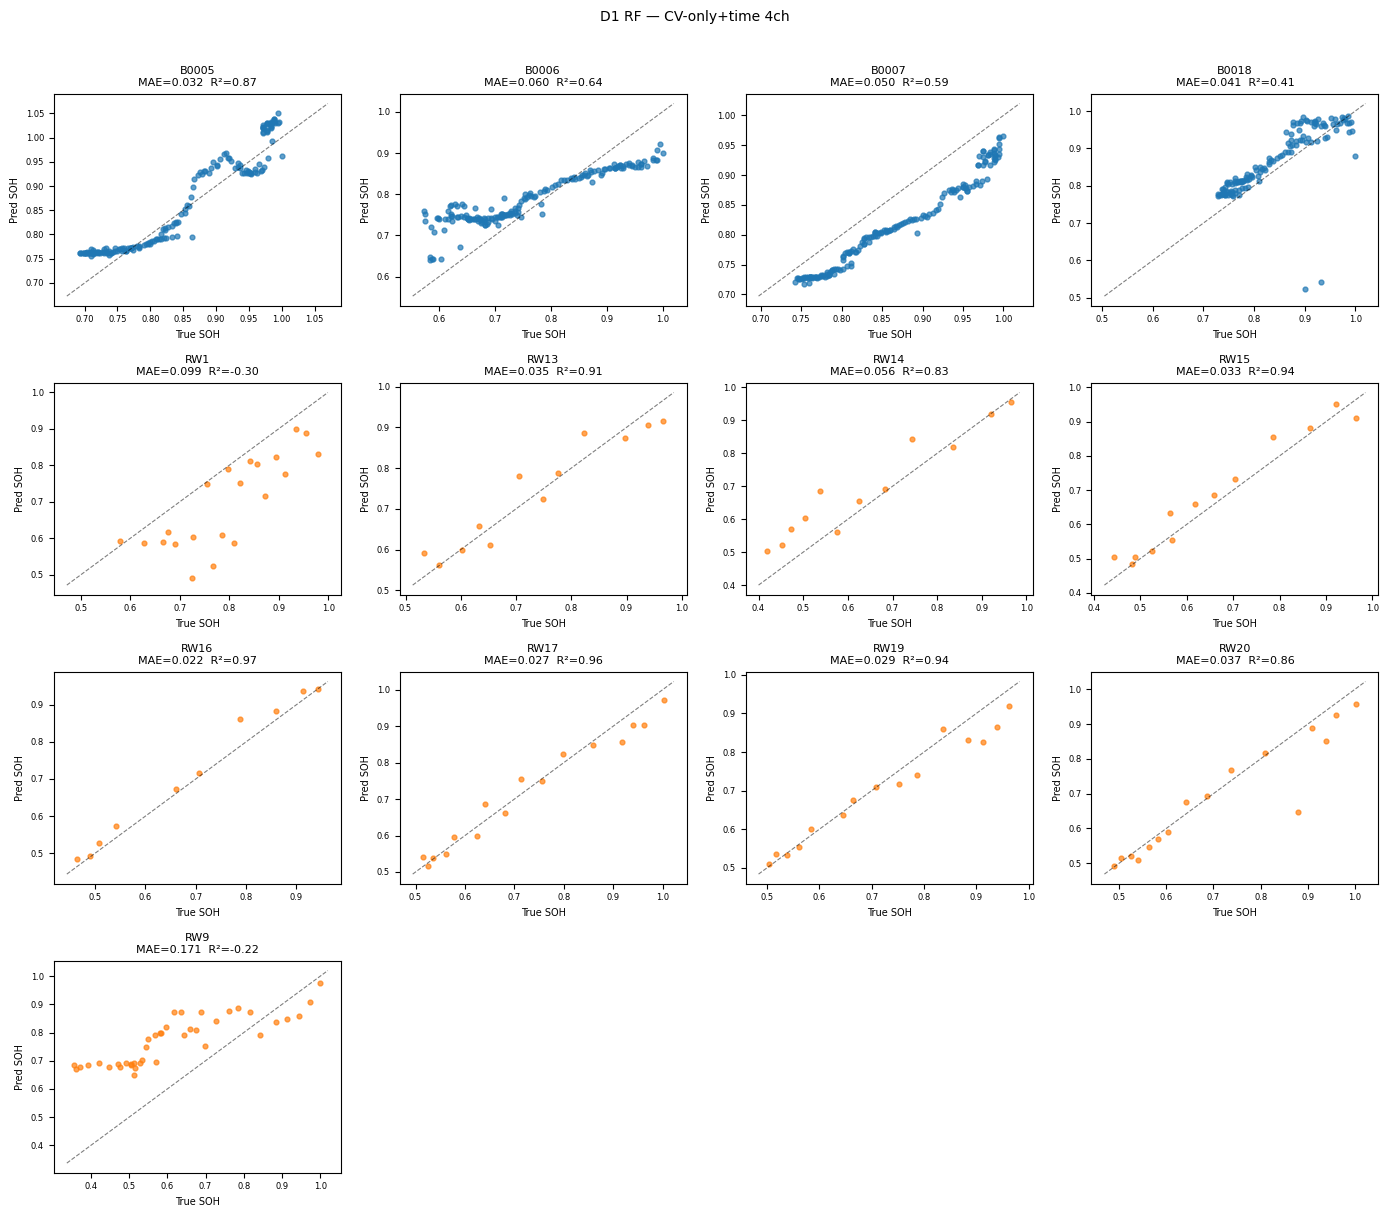

In [ ]:
per_fold_plot(res_d1_rf["per_fold"], "D1 RF — CV-only+time 4ch",
              save_path=RESULTS/"08_d1_rf_per_fold.png")

In [ ]:
# num_layers=1: locked to historical architecture (reproduces previous 0.0544)
C1 = X1.shape[2]  # 4
arch_d1 = lambda: LSTMRegPooled(C1, hidden=64, dropout=0.25,
                                n_scalars=stress1.shape[1], num_layers=1)
res_d1_lstm = run_lobo_lstm(
    arch_d1, X1, mask_all1, soh1, cap_ahr1, battery1, cycle1,
    C0_field1, scalar_arr=stress1, label="LSTM D1"
)
print_line("D1 LSTM (CV+time, locked arch)", res_d1_lstm)


LOBO LSTM D1:   0%|          | 0/13 [00:00<?, ?fold/s]

KeyboardInterrupt: 

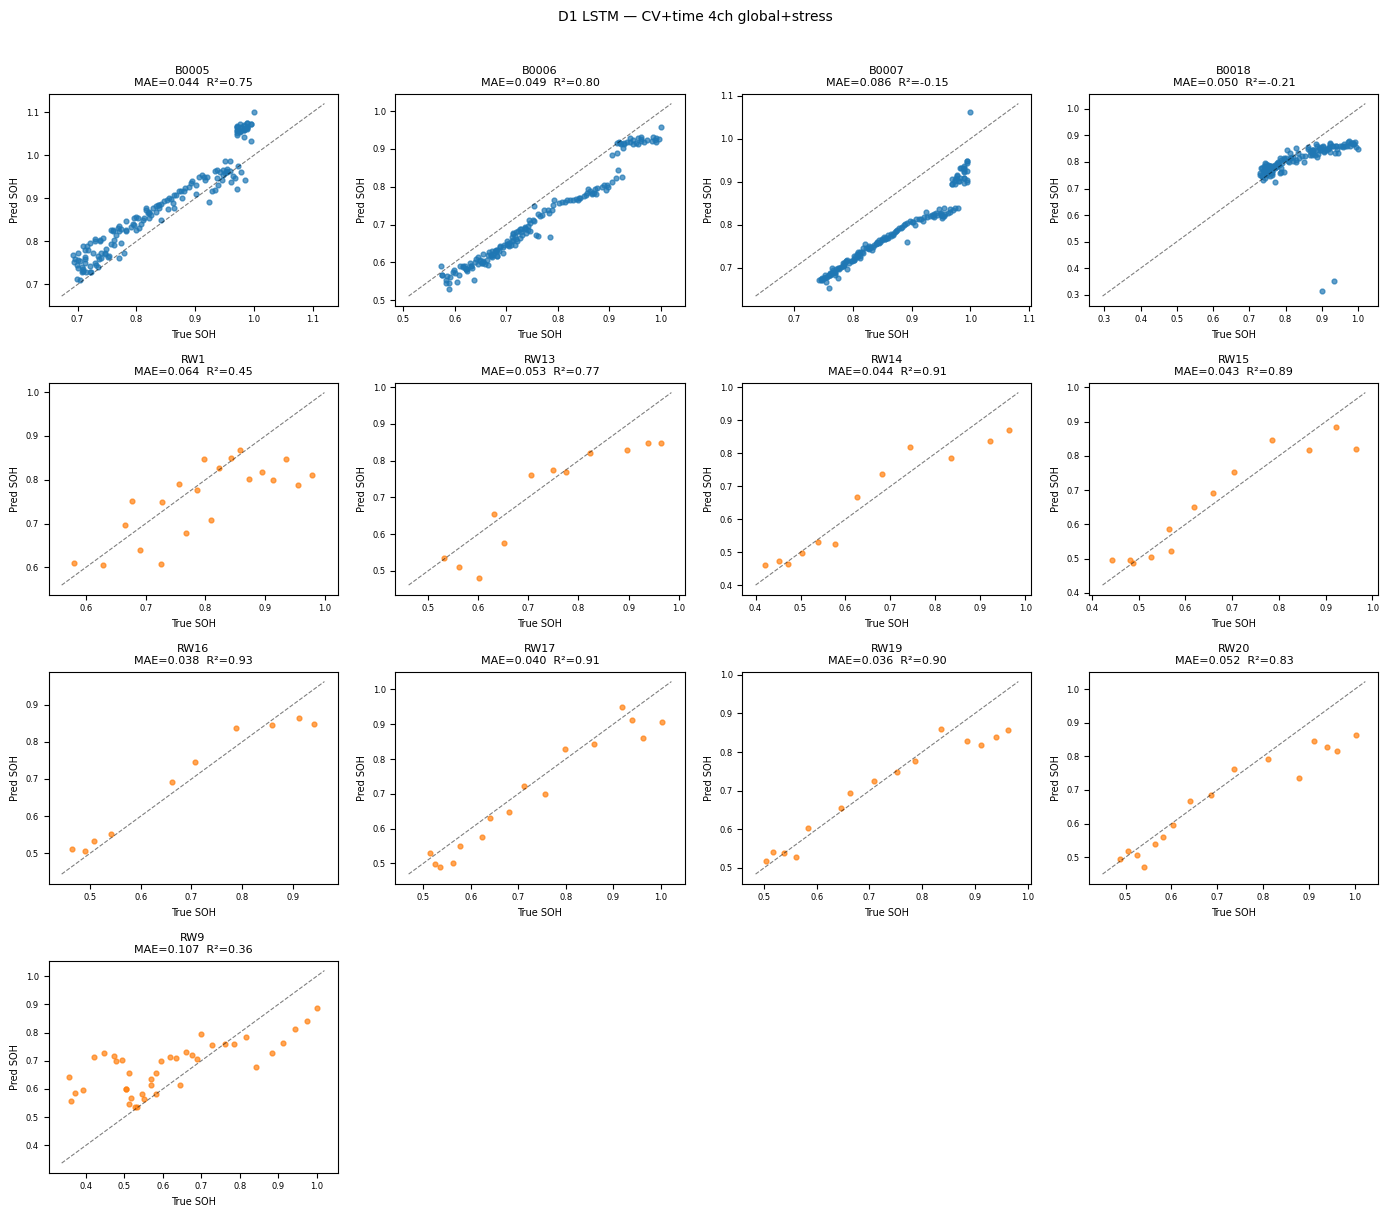

In [ ]:
per_fold_plot(res_d1_lstm["per_fold"], "D1 LSTM — CV+time 4ch global+stress",
              save_path=RESULTS/"08_d1_lstm_per_fold.png")

---
## D2 — Anchored CC+CV + time (4ch) — headline

Full un-laundering: CC ramp from V_ANCHOR to CV onset + duration channel.

In [ ]:
# RF for D2 gets the 9 charge scalars + 6 stress markers + cc_dt + cc_slope (17 features)
cc_extras    = np.stack([cc_dt_arr, cc_slp_arr], axis=1).astype(np.float32)  # (n,2)
rf_d2_feats  = np.concatenate([charge_sc2, stress2, cc_extras], axis=1)
res_d2_rf    = run_lobo_rf(rf_d2_feats, soh2, cap_ahr2, battery2, cycle2,
                            C0_field2, label="RF D2")
print_line("D2 RF (CC+CV+time)", res_d2_rf)

LOBO RF D2:   0%|          | 0/13 [00:00<?, ?it/s]

D2 RF (CC+CV+time)              MAE=0.0401±0.0305  R²=0.725±0.417  skill=0.683


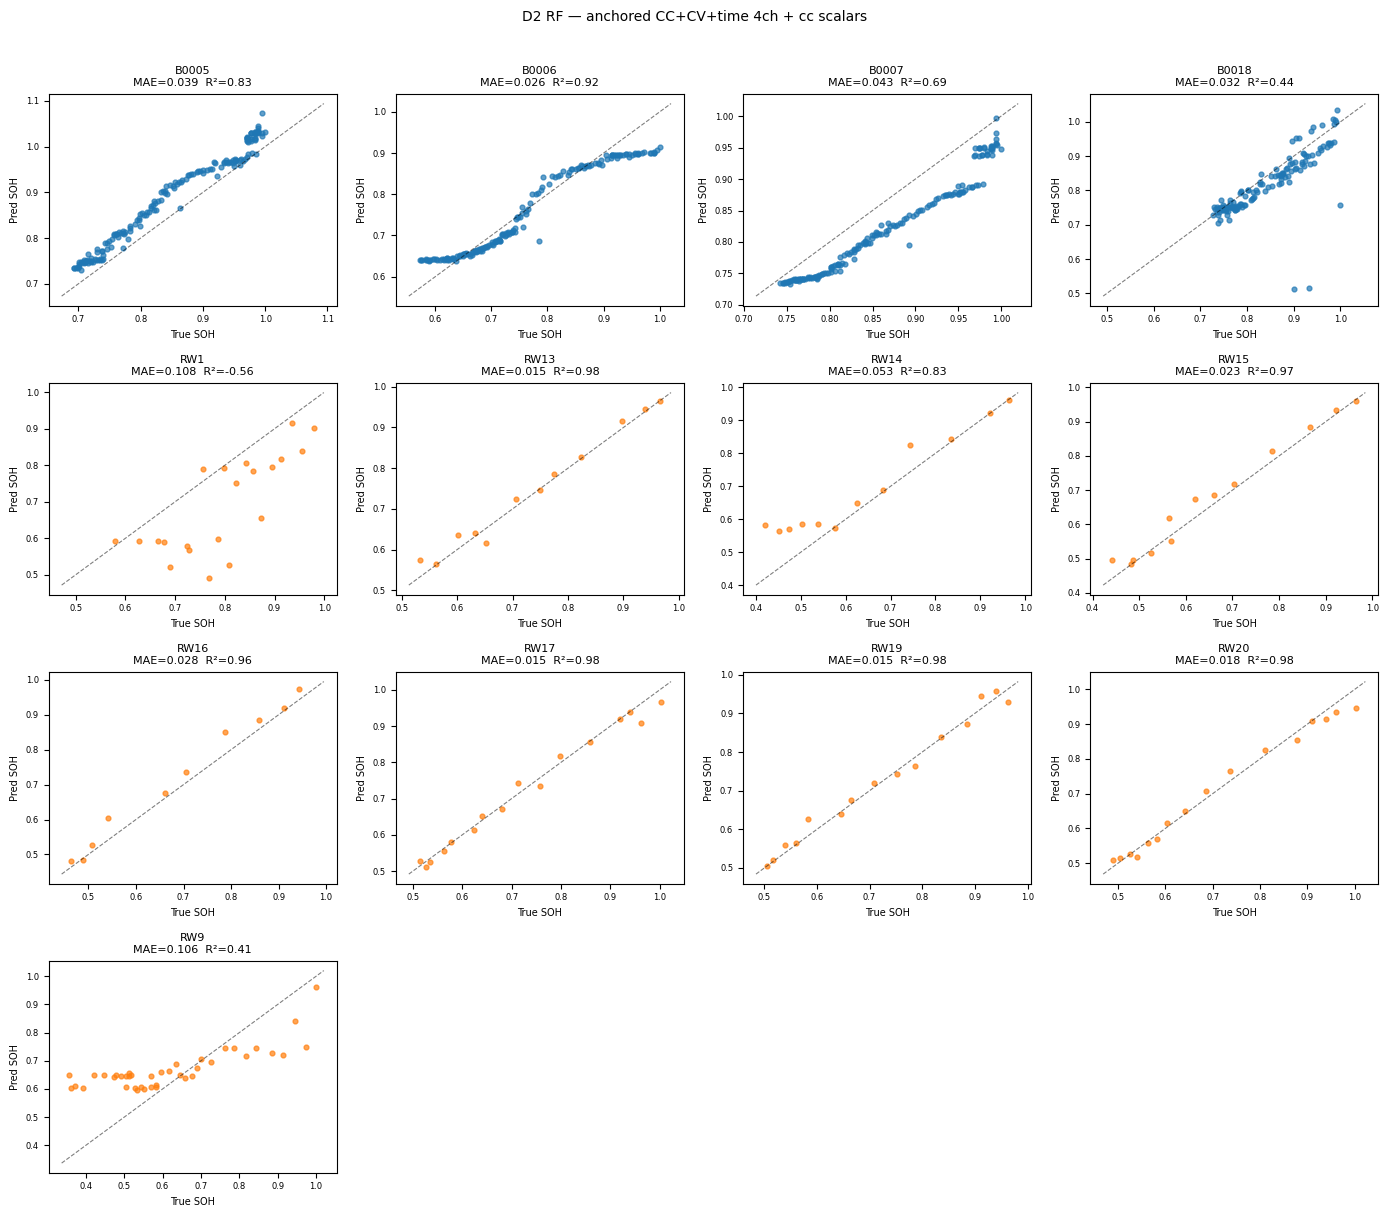

In [ ]:
per_fold_plot(res_d2_rf["per_fold"], "D2 RF — anchored CC+CV+time 4ch + cc scalars",
              save_path=RESULTS/"08_d2_rf_per_fold.png")

In [ ]:
# num_layers=1: locked to historical architecture
C2 = X2.shape[2]  # 4
arch_d2 = lambda: LSTMRegPooled(C2, hidden=64, dropout=0.25,
                                n_scalars=stress2.shape[1], num_layers=1)
res_d2_lstm = run_lobo_lstm(
    arch_d2, X2, mask_all2, soh2, cap_ahr2, battery2, cycle2,
    C0_field2, scalar_arr=stress2, label="LSTM D2"
)
print_line("D2 LSTM (CC+CV+time, locked arch)", res_d2_lstm)


LOBO LSTM D2:   0%|          | 0/13 [00:00<?, ?fold/s]

D2 LSTM (CC+CV+time)            MAE=0.0592±0.0479  R²=0.490±0.639  skill=0.546


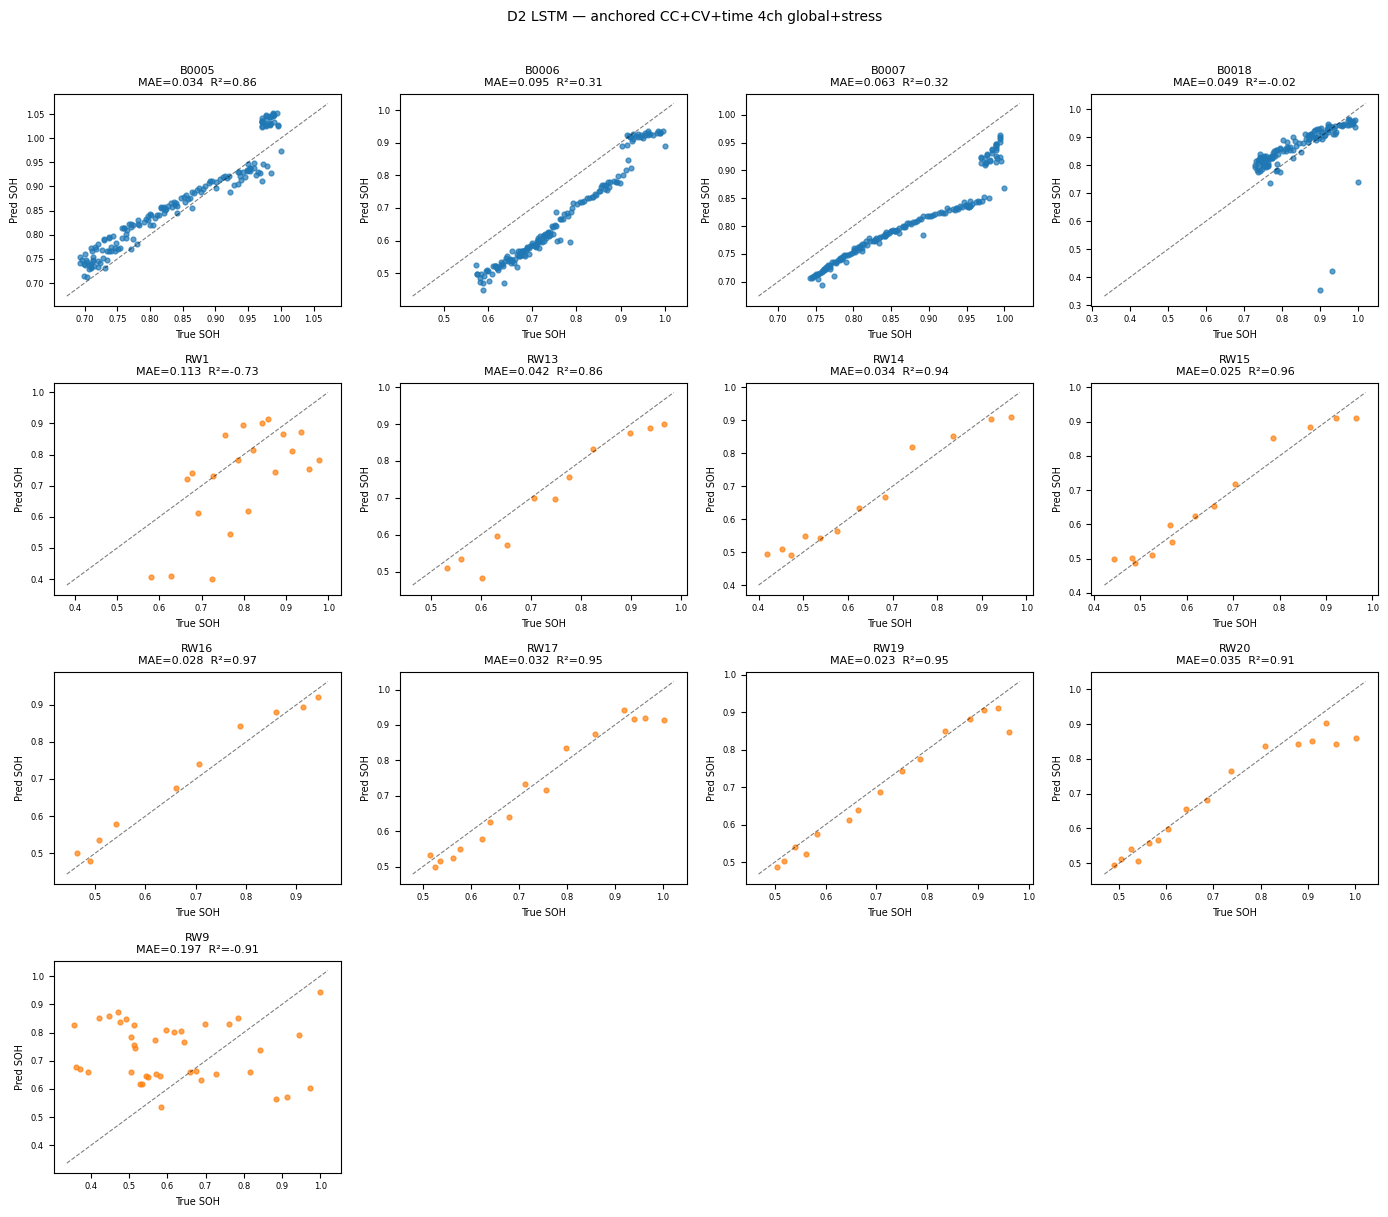

In [ ]:
per_fold_plot(res_d2_lstm["per_fold"], "D2 LSTM — anchored CC+CV+time 4ch global+stress",
              save_path=RESULTS/"08_d2_lstm_per_fold.png")

---
## D3 — D1 curves + cc_dt as explicit scalar

Hypothesis: LSTM can't extract the CC ramp from 10 compressed time steps,
but it *can* use the ramp duration if fed as an explicit scalar.
D3 = D1 curves (CV-only + time, 4ch) + stress markers (6) + cc_dt (1) = **7 scalars**.
If this arm beats D1 LSTM, it confirms the signal is in cc_dt not the ramp shape.
If it ties D2 RF, LSTM closes the gap.

In [ ]:
# Align cc_dt from D2 to D1 key order
# Both datasets use the same pairing logic, so order must be identical
d1_keys = list(zip(battery1, cycle1.astype(int)))
d2_keys = list(zip(battery2, cycle2.astype(int)))
assert d1_keys == d2_keys, "D1/D2 key order mismatch — cannot combine"

# D3 scalars: stress1 (6 features) + cc_dt (1 feature) = 7 total
stress_d3 = np.concatenate([stress1, cc_dt_arr[:, None]], axis=1)  # (n, 7)
print(f"D3 scalars: {stress_d3.shape}")
print(f"cc_dt range: [{cc_dt_arr.min():.0f}, {cc_dt_arr.max():.0f}] s  "
      f"({(cc_dt_arr==0).mean():.0%} zero/fallback)")


D3 scalars: (788, 7)
cc_dt range: [0, 1620] s  (5% zero/fallback)


In [ ]:
# New architecture: hidden=96, num_layers=2, initial-state injection
arch_d3 = lambda: LSTMRegPooled(C1, hidden=64, dropout=0.25, n_scalars=stress_d3.shape[1], num_layers=1)
res_d3_lstm = run_lobo_lstm(
    arch_d3, X1, mask_all1, soh1, cap_ahr1, battery1, cycle1,
    C0_field1, scalar_arr=stress_d3, label="LSTM D3"
)
print_line("D3 LSTM (D1+cc_dt, new arch)", res_d3_lstm)


LOBO LSTM D3:   0%|          | 0/13 [00:00<?, ?fold/s]

D3 LSTM (D1+cc_dt, new arch)    MAE=0.0497±0.0215  R²=0.624±0.438  skill=0.593


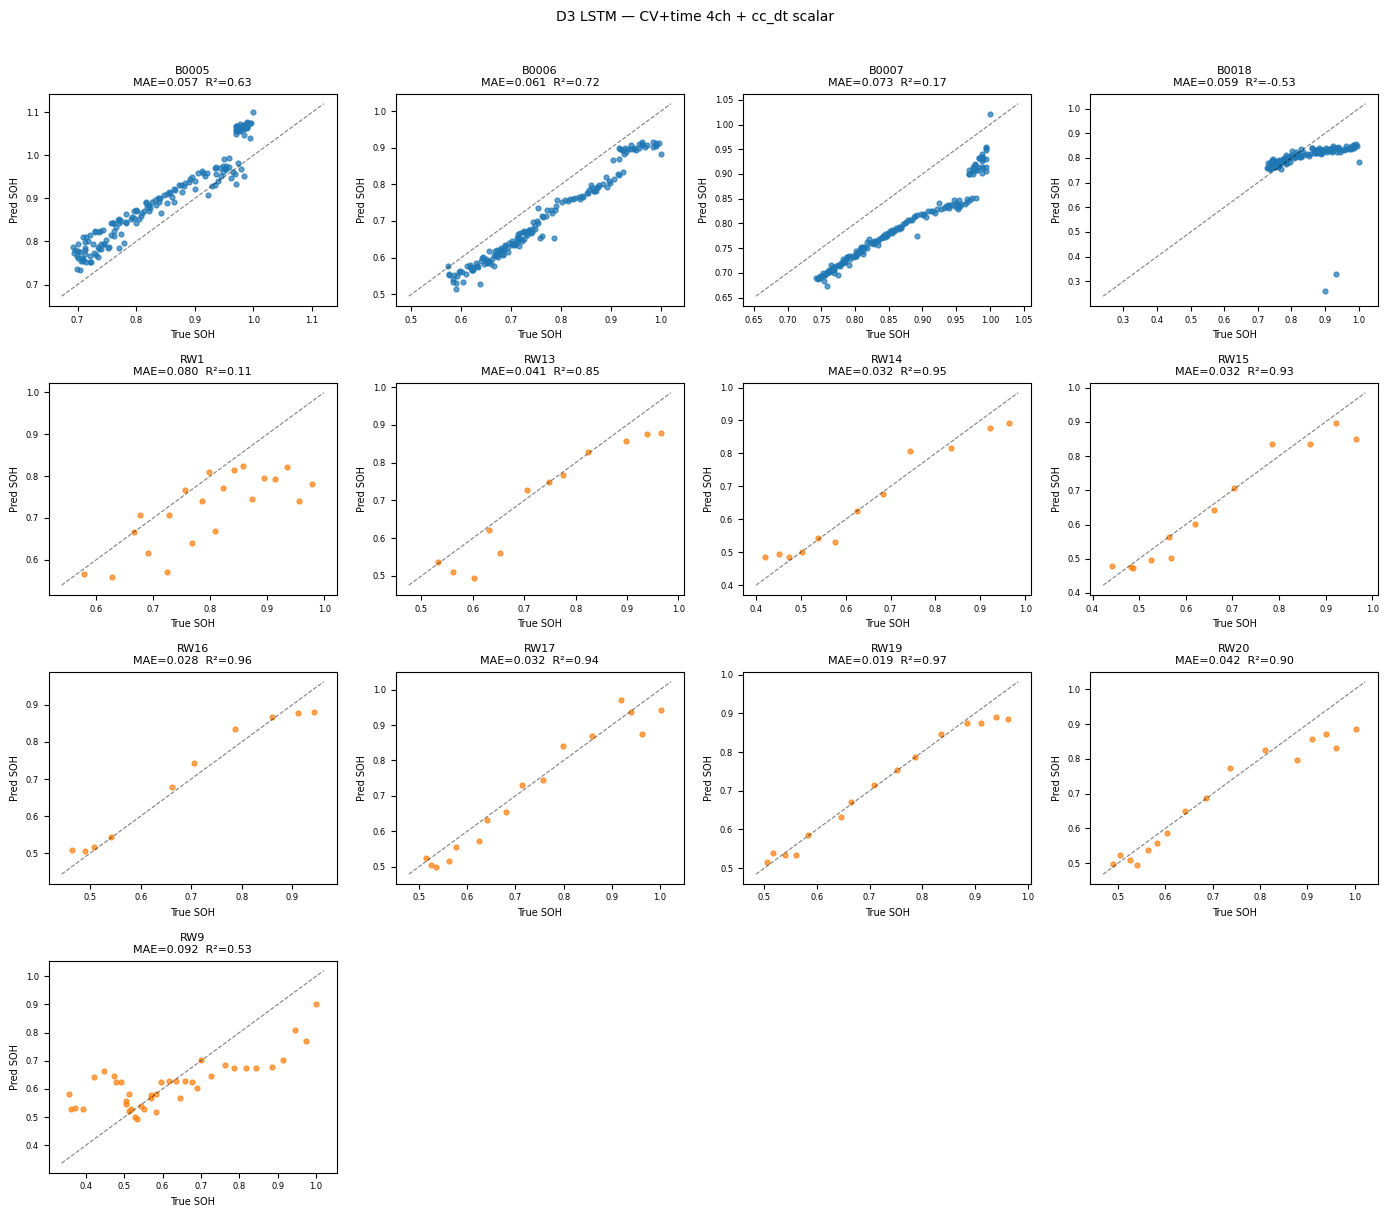

In [ ]:
per_fold_plot(res_d3_lstm["per_fold"],
              "D3 LSTM — CV+time 4ch + cc_dt scalar",
              save_path=RESULTS/"08_d3_lstm_per_fold.png")

---
## D4 — D1 curves + cc_slope as explicit scalar

Hypothesis: Replacing `cc_dt` with `cc_slope` in the D3 scalar set will rescue RW1 SOH predictions (recovering to D1 levels) while maintaining the strong RW9 performance observed in D3, providing a superior model on aggregate with no broken folds.

In [ ]:
# D4 scalars: stress1 (6 features) + cc_slope (1 feature) = 7 total
stress_d4 = np.concatenate([stress1, cc_slp_arr[:, None]], axis=1)  # (n, 7)
print(f"D4 scalars: {stress_d4.shape}")
print(f"cc_slope range: [{cc_slp_arr.min():.4f}, {cc_slp_arr.max():.4f}]")

arch_d4 = lambda: LSTMRegPooled(C1, hidden=64, dropout=0.25, n_scalars=stress_d4.shape[1], num_layers=1)
res_d4_lstm = run_lobo_lstm(
    arch_d4, X1, mask_all1, soh1, cap_ahr1, battery1, cycle1,
    C0_field1, scalar_arr=stress_d4, label="LSTM D4"
)
print_line("D4 LSTM (D1+cc_slope, new arch)", res_d4_lstm)


D4 scalars: (788, 7)
cc_slope range: [0.0000, 0.0028]


LOBO LSTM D4:   0%|          | 0/13 [00:00<?, ?fold/s]

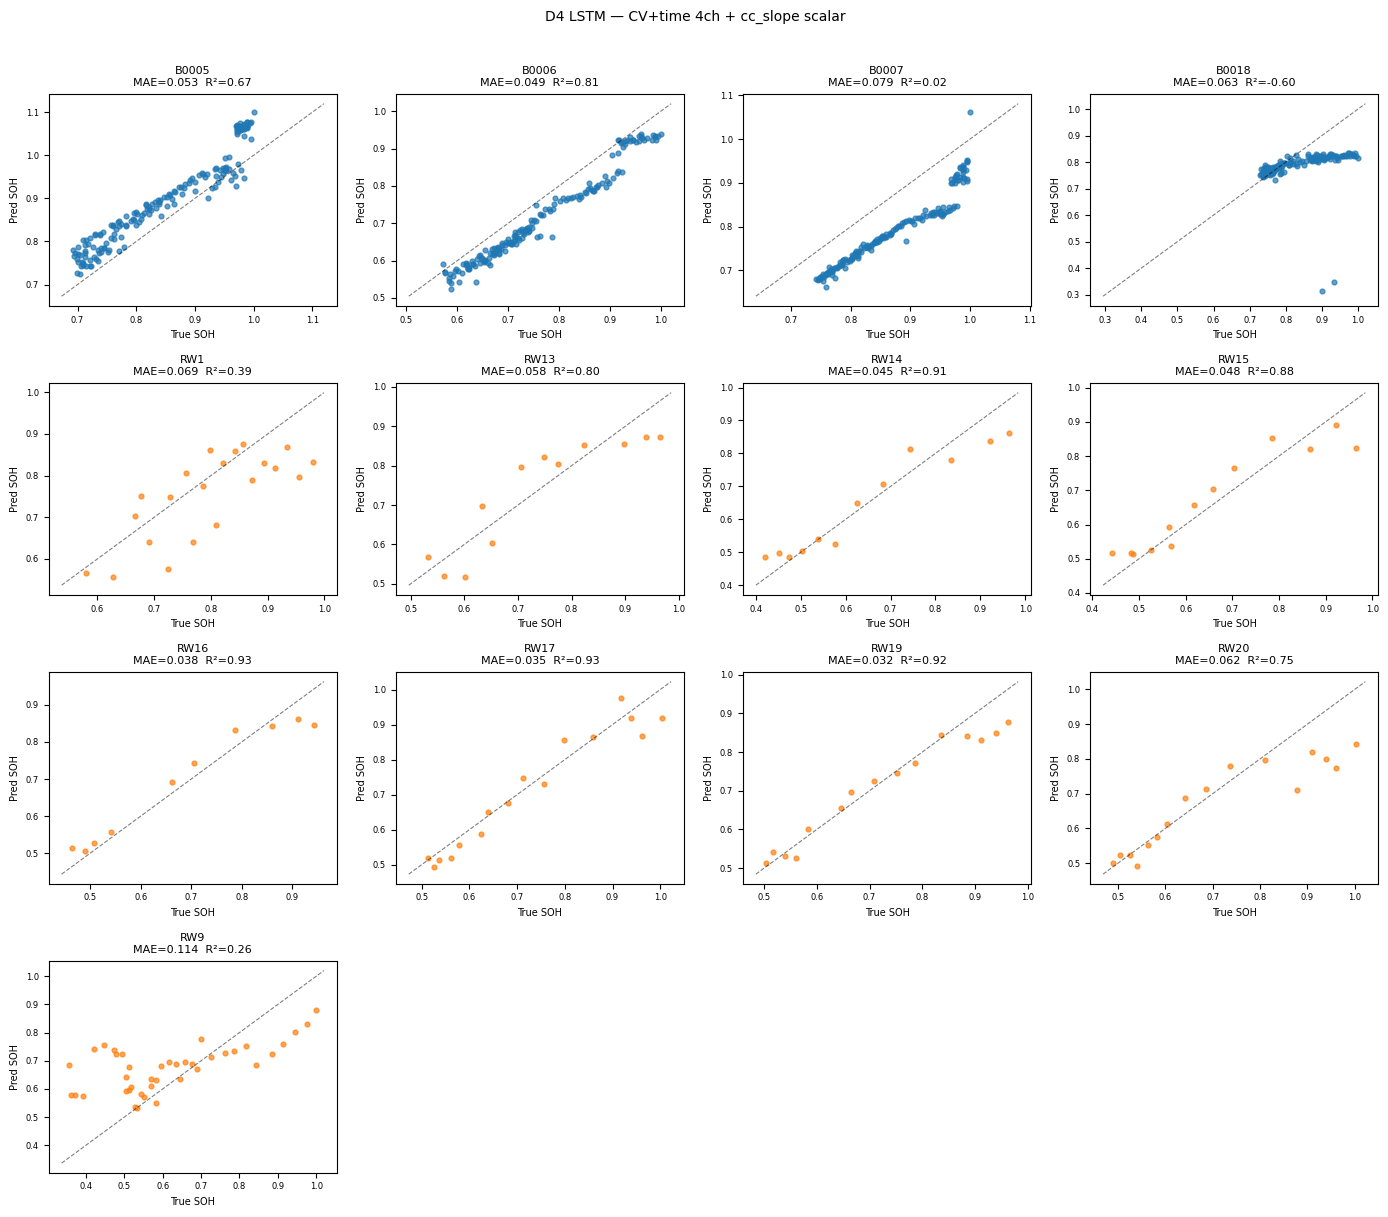

In [ ]:
per_fold_plot(res_d4_lstm["per_fold"],
              "D4 LSTM — CV+time 4ch + cc_slope scalar",
              save_path=RESULTS/"08_d4_lstm_per_fold.png")

---
## D5 — D1 curves + cc_dt/C0 (capacity-normalised ramp duration)

D3 RW1 regressed because **cc_dt is extensive** (proportional to C0).
D4 (cc_slope) fixed RW1 but killed RW9 — slope discards the duration information.
**cc_dt / C0_field** is intensive like slope, but preserves the duration signal.
Same fix as nb07: predict abs Ct then divide by C0 — applied here to the scalar input.


In [ ]:
# cc_dt_norm: intensive ramp duration (s/Ahr) — removes C0 scaling
cc_dt_norm = cc_dt_arr / C0_field1
stress_d5  = np.concatenate([stress1, cc_dt_norm[:, None]], axis=1)  # (n, 7)

print(f"cc_dt_norm stats:")
for bid in ["RW1", "RW9", "B0005"]:
    m = battery1 == bid
    print(f"  {bid}: mean={cc_dt_norm[m].mean():.1f}  std={cc_dt_norm[m].std():.1f} s/Ahr")

arch_d5 = lambda: LSTMRegPooled(C1, hidden=64, dropout=0.25, n_scalars=stress_d5.shape[1], num_layers=1)
res_d5_lstm = run_lobo_lstm(
    arch_d5, X1, mask_all1, soh1, cap_ahr1, battery1, cycle1,
    C0_field1, scalar_arr=stress_d5, label="LSTM D5"
)
print_line("D5 LSTM (D1+cc_dt/C0, new arch)", res_d5_lstm)


In [ ]:
per_fold_plot(res_d5_lstm["per_fold"],
              "D5 LSTM — CV+time 4ch + cc_dt/C0 scalar (new arch)",
              save_path=RESULTS/"08_d5_lstm_per_fold.png")


---
## Phase 3 — Summary


In [ ]:
arms = {
    "D1 RF  (CV+time)":     res_d1_rf,
    "D1 LSTM(CV+time)":     res_d1_lstm,
    "D2 RF  (CC+CV+time)":  res_d2_rf,
    "D2 LSTM(CC+CV+time)":  res_d2_lstm,
    "D3 LSTM(D1+cc_dt)":    res_d3_lstm,
    "D4 LSTM(D1+cc_slope)": res_d4_lstm,
    "D5 LSTM(D1+cc_dt/C0)": res_d5_lstm,
}

def fmt(v, s=None, d=4):
    if v is None or (isinstance(v, float) and np.isnan(v)): return "—"
    base = f"{v:.{d}f}"
    return f"{base} ± {s:.{d}f}" if s is not None else base

print(f"{'Arm':<28}  {'MAE (±std)':>20}  {'R² (±std)':>17}  {'Skill':>7}")
print("-" * 80)
for arm, res in arms.items():
    print(f"{arm:<28}  "
          f"{fmt(res.get('mae'),res.get('mae_std')):>20}  "
          f"{fmt(res.get('r2'),res.get('r2_std'),d=3):>17}  "
          f"{fmt(res.get('skill')):>7}")

print()
print(f"{'Arm':<28}  {'RW1 MAE':>9}  {'RW1 R²':>9}  {'RW9 MAE':>9}  {'RW9 R²':>9}")
print("-" * 72)
for arm, res in arms.items():
    fd  = {f["battery"]: f for f in res["per_fold"]}
    rw1 = fd.get("RW1", {}); rw9 = fd.get("RW9", {})
    print(f"{arm:<28}  "
          f"{rw1.get('mae', float('nan')):>9.4f}  "
          f"{rw1.get('r2',  float('nan')):>9.3f}  "
          f"{rw9.get('mae', float('nan')):>9.4f}  "
          f"{rw9.get('r2',  float('nan')):>9.3f}")

print()
print("Best models:")
best_rf   = min([(r['mae'], k) for k, r in arms.items() if 'RF' in k])
best_lstm = min([(r['mae'], k) for k, r in arms.items() if 'LSTM' in k])
print(f"  RF:   {best_rf[1]}  MAE={best_rf[0]:.4f}")
print(f"  LSTM: {best_lstm[1]}  MAE={best_lstm[0]:.4f}")
fd5 = {f["battery"]: f for f in res_d5_lstm["per_fold"]}
fd3 = {f["battery"]: f for f in res_d3_lstm["per_fold"]}
fd1 = {f["battery"]: f for f in res_d1_lstm["per_fold"]}
print(f"  D5 RW1 R²={fd5['RW1']['r2']:.3f} (guard >=0.10: {'OK' if fd5['RW1']['r2']>=0.10 else 'BROKEN'})  "
      f"RW9 R²={fd5['RW9']['r2']:.3f} (D3: {fd3['RW9']['r2']:.3f}  D1: {fd1['RW9']['r2']:.3f})")


Arm                                         MAE (±std)          R² (±std)    Skill
------------------------------------------------------------------------------------
D1 RF  (CV+time)                       0.0534 ± 0.0391      0.647 ± 0.418   0.6024
D1 LSTM(CV+time)                       0.0544 ± 0.0198      0.627 ± 0.384   0.5799
D2 RF  (CC+CV+time)                    0.0401 ± 0.0305      0.725 ± 0.417   0.6834
D2 LSTM(CC+CV+time)                    0.0592 ± 0.0479      0.490 ± 0.639   0.5457
D3 LSTM(D1+cc_dt)                      0.0497 ± 0.0215      0.624 ± 0.438   0.5928
D4 LSTM(D1+cc_slope)                   0.0573 ± 0.0210      0.591 ± 0.442   0.5543

Arm                                 RW1 MAE     RW1 R²    RW9 MAE     RW9 R²
----------------------------------------------------------------------------
D1 RF  (CV+time)                     0.0988     -0.299     0.1713     -0.215
D1 LSTM(CV+time)                     0.0640      0.446     0.1071      0.361
D2 RF  (CC+CV+time)      